In [44]:
from langchain_core.tools import tool
from langchain_openai import ChatOpenAI
from langgraph.graph import StateGraph,MessagesState,START,END
from dotenv import load_dotenv
load_dotenv()

True

## from langgraph.prebuilt import ToolNode and ToolCondition

In [45]:
from langgraph.prebuilt import ToolNode,tools_condition

In [46]:
@tool
def multiply(a:int,b:int)->int:
    "this function is used to multiply two integers"
    return a*b

In [47]:
tools= [multiply]

In [48]:
llm = ChatOpenAI(model='gpt-4o-mini').bind_tools(tools)

In [49]:
def agent_node(state:MessagesState):
    "llm node that may give answer or request a tool call"
    response = llm.invoke(state['messages'])
    return {'messages':[response]}

In [50]:
builder = StateGraph(state_schema=MessagesState)

In [51]:
builder.add_node('agent_node',agent_node)
builder.add_node('tools',ToolNode(tools))

In [52]:
builder.add_conditional_edges(
    'agent_node',
    path=tools_condition,
    path_map={
        'tools': 'tools', # if tool requested go to the tools node
        END : END # if no tool requested finish execution
    }
)

In [56]:
builder.add_edge(START,'agent_node')

In [57]:
builder.add_edge('tools','agent_node')

In [58]:
graph = builder.compile()

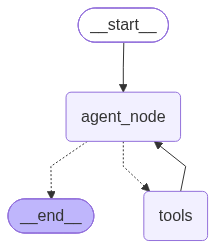

In [59]:
graph

In [60]:
from langchain_core.messages import HumanMessage

In [61]:
graph.invoke(input={
    'messages':[HumanMessage(content='hello')]
})

{'messages': [HumanMessage(content='hello', additional_kwargs={}, response_metadata={}, id='2b5af602-e3e2-409a-8df0-77bef6cfe276'),
  AIMessage(content='Hello! How can I assist you today?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 10, 'prompt_tokens': 50, 'total_tokens': 60, 'completion_tokens_details': {'accepted_prediction_tokens': None, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': None, 'text_tokens': None, 'image_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': 0, 'cached_tokens': 0, 'image_tokens': None, 'text_tokens': None, 'video_tokens': 0}, 'cost': 1.35e-05, 'is_byok': False, 'cost_details': {'upstream_inference_cost': 1.35e-05, 'upstream_inference_prompt_cost': 7.5e-06, 'upstream_inference_completions_cost': 6e-06}}, 'model_provider': 'openai', 'model_name': 'openai/gpt-4o-mini', 'system_fingerprint': 'fp_14f4ce979a', 'id': 'gen-1789037424-peiFoowUebnwqYmxLN1A', 'fini

In [62]:
graph.invoke(input={
    'messages':[HumanMessage(content='can you multiply 100 and 4')]
})

{'messages': [HumanMessage(content='can you multiply 100 and 4', additional_kwargs={}, response_metadata={}, id='8ced8668-72e2-4d72-bafc-ab3e27836953'),
  AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 17, 'prompt_tokens': 57, 'total_tokens': 74, 'completion_tokens_details': {'accepted_prediction_tokens': None, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': None, 'text_tokens': None, 'image_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': 0, 'cached_tokens': 0, 'image_tokens': None, 'text_tokens': None, 'video_tokens': 0}, 'cost': 1.875e-05, 'is_byok': False, 'cost_details': {'upstream_inference_cost': 1.875e-05, 'upstream_inference_prompt_cost': 8.55e-06, 'upstream_inference_completions_cost': 1.02e-05}}, 'model_provider': 'openai', 'model_name': 'openai/gpt-4o-mini', 'system_fingerprint': 'fp_14f4ce979a', 'id': 'gen-1789037457-8KHgmAn41hO2kvL4gSD1', 'finish_reas